In [1]:
# 패키지 import
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 시각화의 선명도를 높임
%config InlineBackend.figure_format = "retina"

# 한글설정
plt.rc('font', family='Malgun Gothic') # 윈도우즈
plt.rc('axes', unicode_minus=False) # 축의 - 깨짐 방지

# 다른 폰트를 기본으로 하려면
# import matplotlib.font_manager as fm
# font_file = 'C:/Windows/Fonts/HMKMAMI.TTF'
# font_name = fm.FontProperties(fname=font_file,
#                              # size = 10
#                              ).get_name()
# plt.rc('font',family=font_name)
    
# warning(경고) 안보이게
import warnings
# warnings.filterwarnings(action='default')
# warnings.filterwarnings(action='ignore') # 경고 메세지 무시

In [3]:
df_first = pd.read_csv('C:/ai_x/download/shareData/부동산_250213/전국 평균 평당 분양가격(2013년 9월부터 2015년 8월까지).csv',
                      encoding='cp949')
df_first.head()

,지역,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,...,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
0,서울,18189,17925,17925,18016,18098,19446,18867,18742,19274,...,20242,20269,20670,20670,19415,18842,18367,18374,18152,18443
1,부산,8111,8111,9078,8965,9402,9501,9453,9457,9411,...,9208,9208,9204,9235,9279,9327,9345,9515,9559,9581
2,대구,8080,8080,8077,8101,8267,8274,8360,8360,8370,...,8439,8253,8327,8416,8441,8446,8568,8542,8542,8795
3,인천,10204,10204,10408,10408,10000,9844,10058,9974,9973,...,10020,10020,10017,9876,9876,9938,10551,10443,10443,10449
4,광주,6098,7326,7611,7346,7346,7523,7659,7612,7622,...,7752,7748,7752,7756,7861,7914,7877,7881,8089,8231


In [6]:
df_first.isnull().sum()

지역          0
2013년12월    0
2014년1월     0
2014년2월     0
2014년3월     0
2014년4월     0
2014년5월     0
2014년6월     0
2014년7월     0
2014년8월     0
2014년9월     0
2014년10월    0
2014년11월    0
2014년12월    0
2015년1월     0
2015년2월     0
2015년3월     0
2015년4월     0
2015년5월     0
2015년6월     0
2015년7월     0
2015년8월     0
dtype: int64

In [9]:
df_first.set_index('지역', inplace=True)

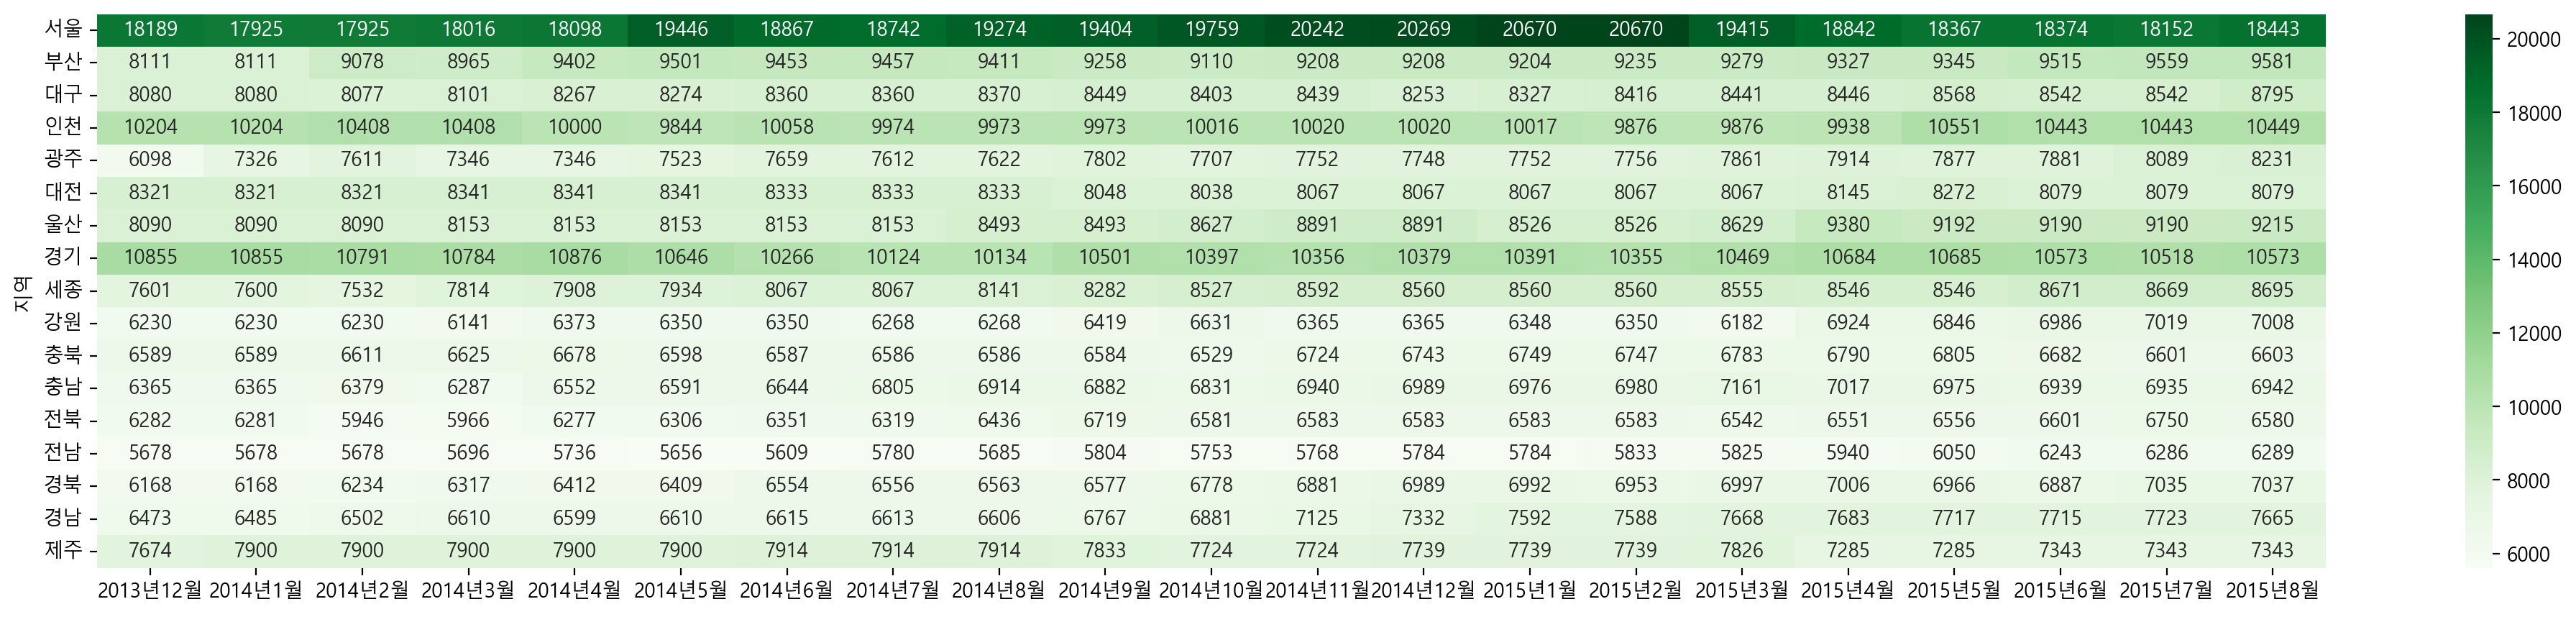

In [15]:
df_first.head()
plt.figure(figsize=(25,5))
sns.heatmap(df_first, annot=True, fmt='d', cmap='Greens')
plt.show()

In [53]:
df_last = pd.read_csv('data/전국제곱미터당분양가격(2015년10월부터).csv')
df_last.head(1)

,지역명,규모구분,연도,월,분양가격(제곱미터)
0,서울,모든면적,2015,10,"5,841"


In [54]:
def commadrop2(price):
    if pd.isna(price):
        return np.nan
    elif price.strip() == '':
        return np.nan
    elif price.find(',') != -1:
        return int(price.replace(',',''))
    else:
        return int(price)

In [55]:
df_last['제곱미터당분양가격'] = df_last['분양가격(제곱미터)'].map(commadrop2)
df_last.head()

,지역명,규모구분,연도,월,분양가격(제곱미터),제곱미터당분양가격
0,서울,모든면적,2015,10,"5,841",5841.0
1,서울,전용면적 60제곱미터이하,2015,10,5652,5652.0
2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,5882,5882.0
3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,5721,5721.0
4,서울,전용면적 102제곱미터초과,2015,10,5879,5879.0


In [56]:
df_last['평당분양가격'] = df_last['제곱미터당분양가격']*3.3
df_last.head()

,지역명,규모구분,연도,월,분양가격(제곱미터),제곱미터당분양가격,평당분양가격
0,서울,모든면적,2015,10,"5,841",5841.0,19275.3
1,서울,전용면적 60제곱미터이하,2015,10,5652,5652.0,18651.6
2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,5882,5882.0,19410.6
3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,5721,5721.0,18879.3
4,서울,전용면적 102제곱미터초과,2015,10,5879,5879.0,19400.7


In [58]:
df_last.drop(['제곱미터당분양가격'], axis=1, inplace=True)
df_last.sample(1)

,지역명,규모구분,연도,월,분양가격(제곱미터),평당분양가격
8836,제주,전용면적 60제곱미터이하,2024,5,,NaN


In [59]:
df_last.drop(['분양가격(제곱미터)'], axis=1, inplace=True)
df_last.sample(1)

,지역명,규모구분,연도,월,평당분양가격
4932,서울,전용면적 60제곱미터초과 85제곱미터이하,2020,8,26545.2


In [62]:
df_last.rename(columns={'규모구분': '전용면적'}, inplace=True)

In [63]:
df_last

,지역명,전용면적,연도,월,평당분양가격
0,서울,모든면적,2015,10,19275.3
1,서울,전용면적 60제곱미터이하,2015,10,18651.6
2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,19410.6
3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,18879.3
4,서울,전용면적 102제곱미터초과,2015,10,19400.7
...,...,...,...,...,...
9090,제주,모든면적,2024,8,25419.9
9091,제주,전용면적 60제곱미터이하,2024,8,NaN
9092,제주,전용면적 60제곱미터초과 85제곱미터이하,2024,8,24799.5
9093,제주,전용면적 85제곱미터초과 102제곱미터이하,2024,8,NaN


In [66]:
df_last.groupby(['연도','지역명'])['평당분양가격'].mean().unstack().round(0)

지역명,강원,경기,경남,경북,광주,대구,대전,부산,서울,세종,울산,인천,전남,전북,제주,충남,충북
연도,,,,,,,,,,,,,,,,,
2015,7188.0,11061.0,8459.0,7464.0,7917.0,9019.0,8191.0,10377.0,20316.0,8765.0,9368.0,10976.0,6799.0,7110.0,7951.0,7690.0,6829.0
2016,7163.0,11685.0,8497.0,7753.0,9191.0,10282.0,8911.0,10744.0,21753.0,8858.0,9583.0,11099.0,6937.0,6907.0,9567.0,7958.0,7133.0
2017,7319.0,12296.0,8807.0,8288.0,9600.0,12192.0,9913.0,11638.0,21864.0,9133.0,10630.0,11672.0,7413.0,7406.0,12629.0,8157.0,7463.0
2018,8219.0,14258.0,9328.0,8681.0,9527.0,12139.0,10234.0,12890.0,23202.0,10340.0,10241.0,11882.0,7930.0,8175.0,11936.0,8202.0,8149.0
2019,8934.0,15666.0,10698.0,9050.0,12112.0,14082.0,12619.0,13538.0,28287.0,11299.0,10216.0,13250.0,8219.0,8532.0,11828.0,8749.0,7971.0
2020,10302.0,15106.0,10919.0,9998.0,13406.0,15314.0,11239.0,13353.0,29781.0,11628.0,12838.0,14983.0,9562.0,8559.0,14193.0,9139.0,8359.0
2021,10291.0,14567.0,11302.0,11227.0,13710.0,15586.0,11994.0,14318.0,29380.0,12578.0,14192.0,15774.0,9981.0,9048.0,22302.0,9861.0,8822.0
2022,11644.0,16622.0,12456.0,12018.0,15096.0,16822.0,14114.0,18167.0,29129.0,11310.0,17904.0,17342.0,10636.0,10003.0,18954.0,11730.0,10034.0
2023,13409.0,20175.0,13283.0,13025.0,17958.0,17657.0,17917.0,20471.0,33231.0,12278.0,18832.0,16151.0,11847.0,10966.0,24096.0,12581.0,11104.0


<Axes: xlabel='연도', ylabel='평당분양가격'>

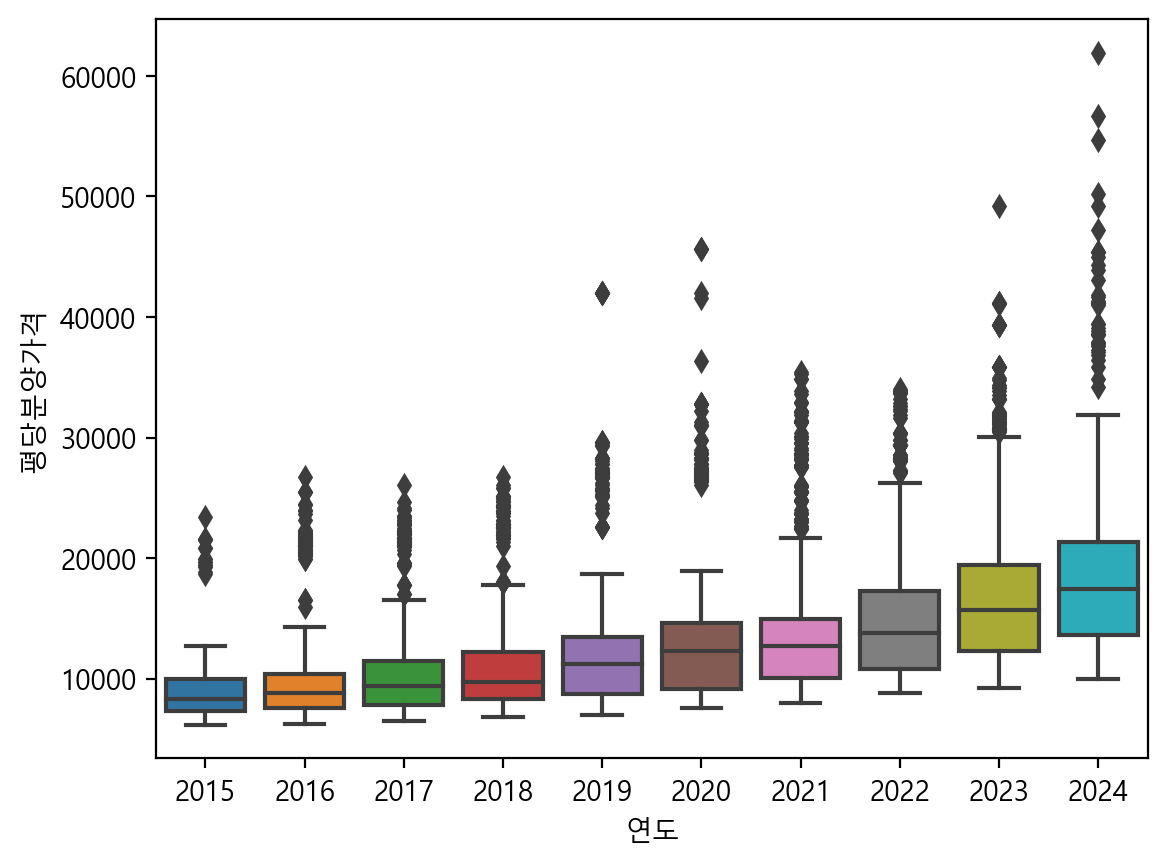

In [68]:
sns.boxplot(data=df_last, x='연도', y='평당분양가격')

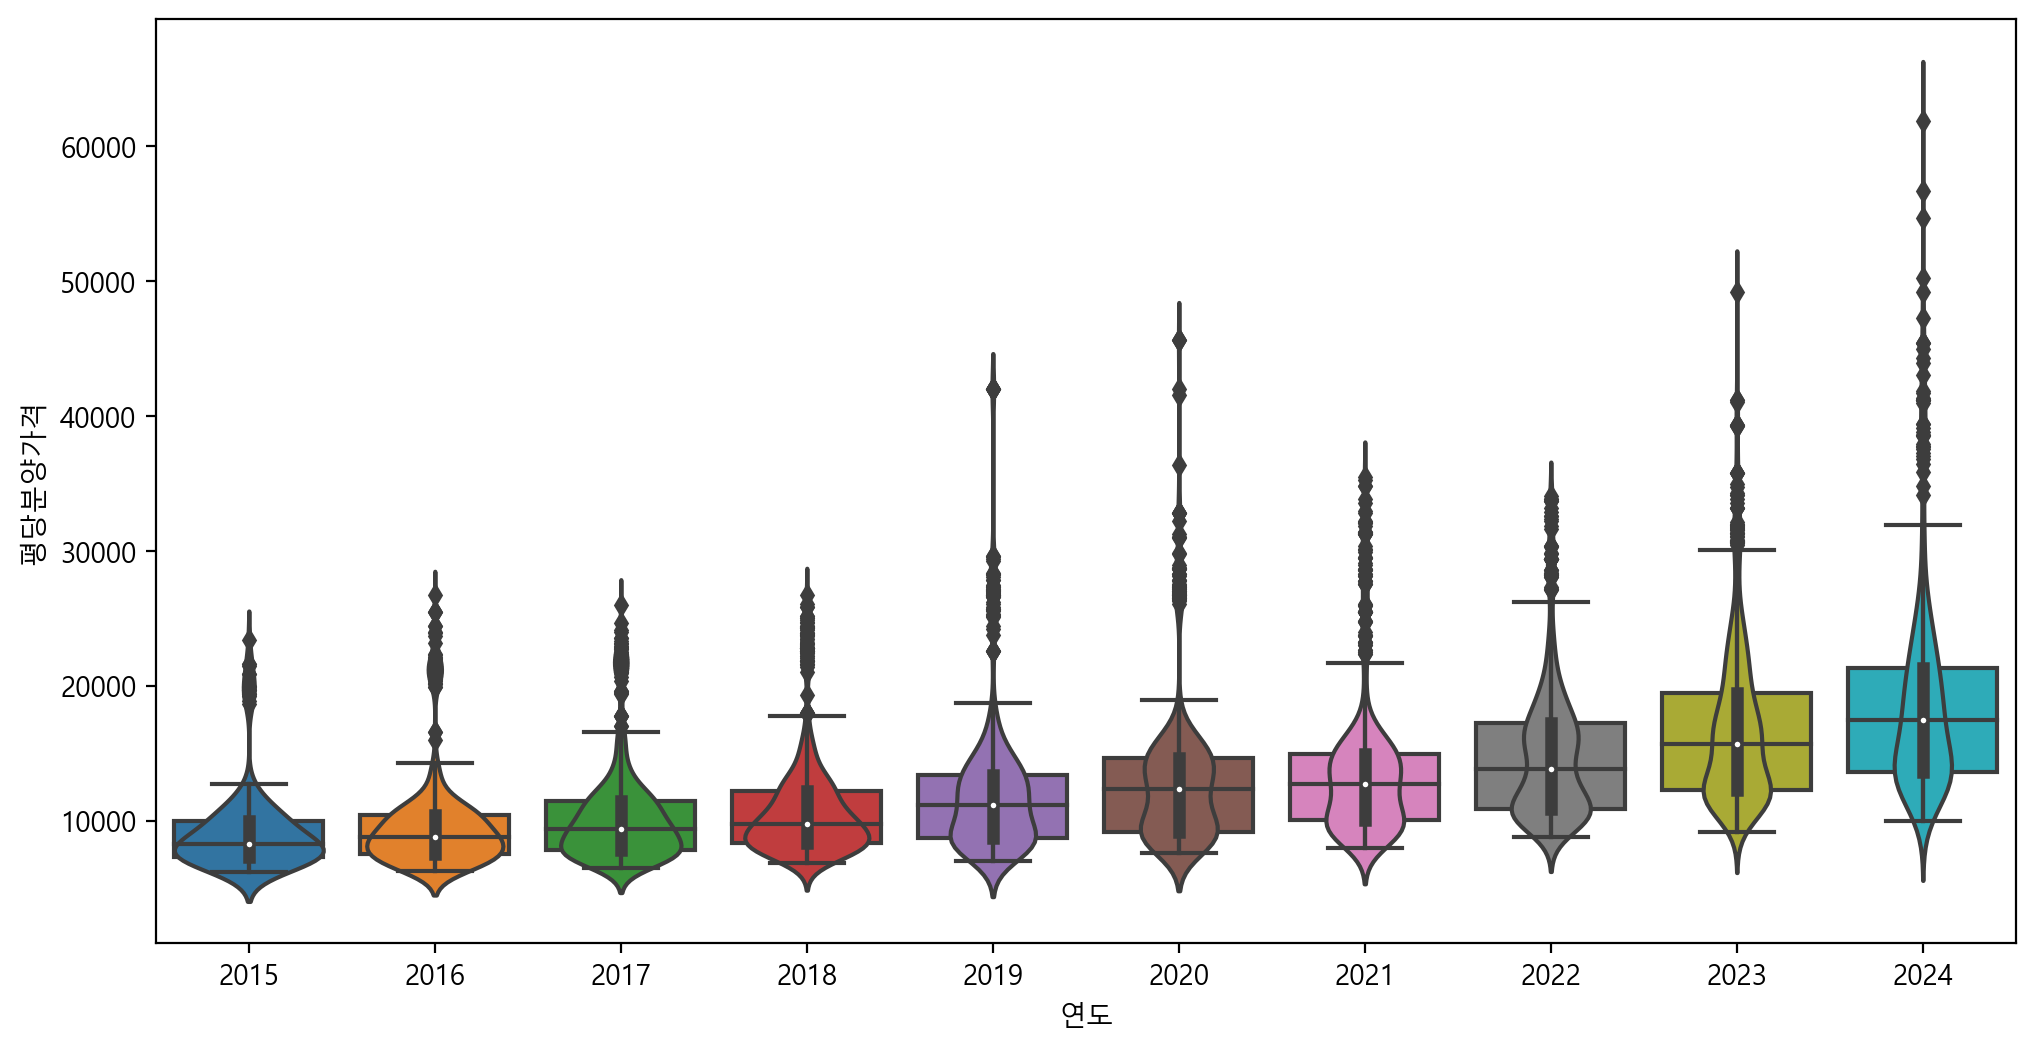

In [74]:
plt.figure(figsize=(12, 6))

sns.violinplot(
    data=df_last,
    x='연도',
    y='평당분양가격'
)

sns.boxplot(
    data=df_last,
    x='연도',
    y='평당분양가격'
)
plt.show()

In [76]:
df_last

,지역명,전용면적,연도,월,평당분양가격
0,서울,모든면적,2015,10,19275.3
1,서울,전용면적 60제곱미터이하,2015,10,18651.6
2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,19410.6
3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,18879.3
4,서울,전용면적 102제곱미터초과,2015,10,19400.7
...,...,...,...,...,...
9090,제주,모든면적,2024,8,25419.9
9091,제주,전용면적 60제곱미터이하,2024,8,NaN
9092,제주,전용면적 60제곱미터초과 85제곱미터이하,2024,8,24799.5
9093,제주,전용면적 85제곱미터초과 102제곱미터이하,2024,8,NaN


In [77]:
df_first

,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,2014년9월,...,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
지역,,,,,,,,,,,,,,,,,,,,,
서울,18189,17925,17925,18016,18098,19446,18867,18742,19274,19404,...,20242,20269,20670,20670,19415,18842,18367,18374,18152,18443
부산,8111,8111,9078,8965,9402,9501,9453,9457,9411,9258,...,9208,9208,9204,9235,9279,9327,9345,9515,9559,9581
대구,8080,8080,8077,8101,8267,8274,8360,8360,8370,8449,...,8439,8253,8327,8416,8441,8446,8568,8542,8542,8795
인천,10204,10204,10408,10408,10000,9844,10058,9974,9973,9973,...,10020,10020,10017,9876,9876,9938,10551,10443,10443,10449
광주,6098,7326,7611,7346,7346,7523,7659,7612,7622,7802,...,7752,7748,7752,7756,7861,7914,7877,7881,8089,8231
대전,8321,8321,8321,8341,8341,8341,8333,8333,8333,8048,...,8067,8067,8067,8067,8067,8145,8272,8079,8079,8079
울산,8090,8090,8090,8153,8153,8153,8153,8153,8493,8493,...,8891,8891,8526,8526,8629,9380,9192,9190,9190,9215
경기,10855,10855,10791,10784,10876,10646,10266,10124,10134,10501,...,10356,10379,10391,10355,10469,10684,10685,10573,10518,10573
세종,7601,7600,7532,7814,7908,7934,8067,8067,8141,8282,...,8592,8560,8560,8560,8555,8546,8546,8671,8669,8695


In [80]:
df_first = pd.read_csv('C:/ai_x/download/shareData/부동산_250213/전국 평균 평당 분양가격(2013년 9월부터 2015년 8월까지).csv',
                      encoding='cp949')
df_first.sample()

,지역,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,...,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
13,전남,5678,5678,5678,5696,5736,5656,5609,5780,5685,...,5768,5784,5784,5833,5825,5940,6050,6243,6286,6289


In [81]:
new_first = df_first.melt(id_vars='지역',
             var_name='연도월',
             value_name='평당분양가격')
new_first.head()

,지역,연도월,평당분양가격
0,서울,2013년12월,18189
1,부산,2013년12월,8111
2,대구,2013년12월,8080
3,인천,2013년12월,10204
4,광주,2013년12월,6098


In [82]:
new_first['연도월'].str.split('년')[0]

['2013', '12월']

In [83]:
def parse_year(data):
    return int(data.split('년')[0])
parse_year('2013년12월')

2013

In [84]:
def parse_month(data):
    return int(data.split('년')[1][:-1])
parse_month('2013년12월')

12

In [85]:
new_first['연도'] = new_first['연도월'].map(lambda data : int(data.split('년')[0]))
new_first.head(1)

,지역,연도월,평당분양가격,연도
0,서울,2013년12월,18189,2013


In [86]:
new_first['월'] = new_first['연도월'].apply(lambda data : int(data.split('년')[1][:-1]))
new_first.head(1)

,지역,연도월,평당분양가격,연도,월
0,서울,2013년12월,18189,2013,12


In [87]:
df_last.head(1)

,지역명,전용면적,연도,월,평당분양가격
0,서울,모든면적,2015,10,19275.3


In [88]:
new_first.drop('연도월', axis=1, inplace=True)
new_first.head(1)

,지역,평당분양가격,연도,월
0,서울,18189,2013,12


In [89]:
new_first.columns = ['지역명','평당분양가격','연도','월']
new_first.tail(1)

,지역명,평당분양가격,연도,월
356,제주,7343,2015,8


In [90]:
new_last = df_last[df_last.전용면적 == '모든면적'].copy()
new_last.drop('전용면적', axis=1, inplace=True)

In [91]:
df = pd.concat( [new_first, new_last], axis=0 )
df.index

Int64Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
            ...
            9045, 9050, 9055, 9060, 9065, 9070, 9075, 9080, 9085, 9090],
           dtype='int64', length=2176)

In [92]:
df.shape

(2176, 4)

In [93]:
df.reset_index(drop=True, inplace=True)

In [95]:
df = df[['지역명','연도','월','평당분양가격']]
df

,지역명,연도,월,평당분양가격
0,서울,2013,12,18189.0
1,부산,2013,12,8111.0
2,대구,2013,12,8080.0
3,인천,2013,12,10204.0
4,광주,2013,12,6098.0
...,...,...,...,...
2171,전북,2024,8,12058.2
2172,전남,2024,8,13120.8
2173,경북,2024,8,13827.0
2174,경남,2024,8,13252.8
